# 01 - Prepare the Existing Electricity Network

**Purpose:** propose which substations are connected by the received transmission routes, estimate how total demand might be shared between substations, and list the information still needed before outage calculations can run.

**Before running:**

- run `00_data_intake.ipynb` or the equivalent preparation command;
- use the repository `.venv` kernel;
- optionally place GridFinder and OSM line files under `data/0-incoming/energy/`;
- remember that the current mapped routes are not yet a confirmed CEB line-by-line network.

**What this notebook does:** writes proposed substations and lines under `data/1-processed/energy/network`; writes estimated demand shares under the cleaned collaborator-data folder; and checks whether line limits, power-station data, substation connections and demand over time are complete.

**What you need to do:** review every proposed line, confirm substation and line names and voltages, add the maximum power each line can carry, complete the power-station register and provide demand over time. The model should not run until these checks are complete.

**Common adjustments:** you can change the distance used to match a mapped route to a substation, the temporary default voltage, the optional OSM/GridFinder files and the method used to share demand. Record these choices. Do not treat estimated distribution routes as confirmed transmission lines.

In [1]:
from pathlib import Path
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from mu_star_energy.distribution import build_service_weights
from mu_star_energy.paths import incoming_energy_dir, processed_energy_dir
from mu_star_energy.topology import build_substation_topology

COLLABORATOR_DIR = processed_energy_dir() / "collaborator"
NETWORK_DIR = processed_energy_dir() / "network"
NETWORK_DIR.mkdir(parents=True, exist_ok=True)

substations = gpd.read_parquet(COLLABORATOR_DIR / "substations.parquet")
routes = gpd.read_parquet(COLLABORATOR_DIR / "transmission_routes.parquet")
result = build_substation_topology(substations, routes, snap_tolerance_m=2500, default_voltage_kv=66)

result.buses.to_parquet(NETWORK_DIR / "buses.parquet")
result.lines.to_parquet(NETWORK_DIR / "lines.parquet")
report = {
    "buses": len(result.buses),
    "lines": len(result.lines),
    "ignored_route_parts": result.ignored_route_parts,
    "line_ratings_complete": bool(not result.lines.empty and result.lines["s_nom_mva"].notna().all()),
}
(NETWORK_DIR / "topology_report.json").write_text(json.dumps(report, indent=2))
display(pd.Series({
    "substations": report["buses"],
    "proposed transmission lines": report["lines"],
    "mapped route sections not connected": report["ignored_route_parts"],
    "all line limits supplied": report["line_ratings_complete"],
}).to_frame("value"))

,value
substations,18
proposed transmission lines,19
mapped route sections not connected,10
all line limits supplied,False


## Proposed connections between substations

The source map sometimes stores several line sections as one record. The code separates those sections, finds substations close to each route and connects neighbouring substations along it. This produces a repeatable first draft for review; it is not yet a confirmed CEB network.

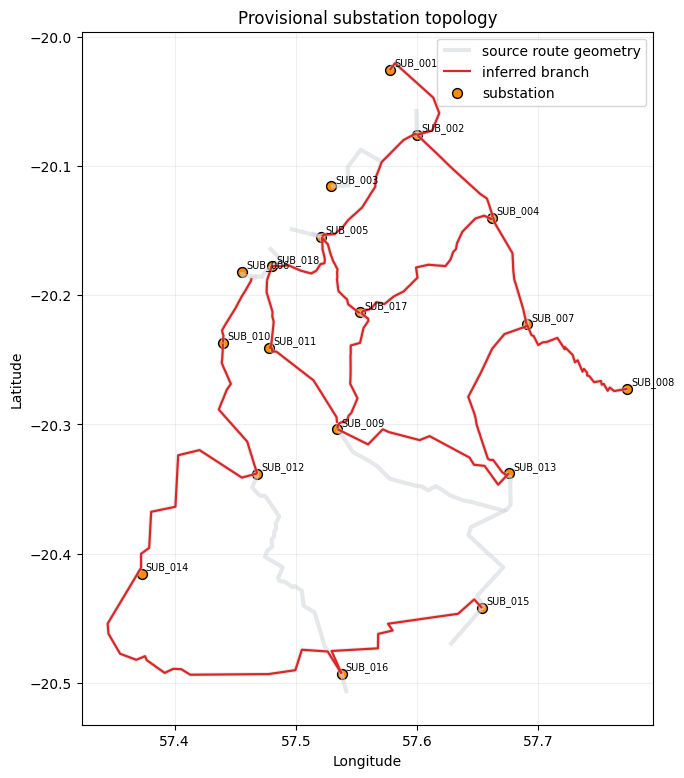

,line ID,first substation,second substation,voltage (kV),length (km),maximum apparent power (MVA),source route section
0,LINE_001,SUB_006,SUB_018,66.0,1.259279,NaN,18
1,LINE_002,SUB_011,SUB_006,66.0,5.915680,NaN,6
2,LINE_003,SUB_010,SUB_006,66.0,6.220298,NaN,10
3,LINE_004,SUB_018,SUB_005,66.0,7.286758,NaN,3
4,LINE_005,SUB_005,SUB_017,66.0,7.687168,NaN,1
5,LINE_006,SUB_009,SUB_011,66.0,9.100065,NaN,7
6,LINE_007,SUB_001,SUB_002,66.0,9.545107,NaN,16
7,LINE_008,SUB_004,SUB_007,66.0,9.754997,NaN,5
8,LINE_009,SUB_002,SUB_004,66.0,9.810400,NaN,2
9,LINE_010,SUB_009,SUB_017,66.0,11.813950,NaN,0


In [2]:
fig, ax = plt.subplots(figsize=(9, 9))
routes.plot(ax=ax, color="#d1d5db", linewidth=3, alpha=0.55, label="source route geometry")
if not result.lines.empty:
    result.lines.plot(ax=ax, color="#dc2626", linewidth=1.6, label="inferred branch")
result.buses.plot(ax=ax, color="#ff8c00", edgecolor="black", markersize=50, label="substation")
for _, row in result.buses.iterrows():
    ax.annotate(row["bus_id"], (row.geometry.x, row.geometry.y), xytext=(3, 3), textcoords="offset points", fontsize=7)
ax.set_title("Provisional substation topology")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

display(
    result.lines.drop(columns="geometry").rename(columns={
        "line_id": "line ID",
        "bus0": "first substation",
        "bus1": "second substation",
        "v_nom_kv": "voltage (kV)",
        "length_km": "length (km)",
        "s_nom_mva": "maximum apparent power (MVA)",
        "route_part": "source route section",
    })
)

## Estimating each substation's share of demand

OSM and GridFinder lines are optional. When available, the code assigns each mapped line section to the nearest transmission substation. The amount of mapped line near each substation is then used as a rough guide to its share of total demand.

This estimate is only for locating customers and demand. GridFinder routes are estimates and are not added to the electrical network calculation.

In [3]:
def optional_line_layer(path):
    if not path.exists():
        return None
    return gpd.read_parquet(path) if path.suffix == ".parquet" else gpd.read_file(path)

gridfinder_path = incoming_energy_dir() / "gridfinder" / "grid.gpkg"
osm_path = incoming_energy_dir() / "osm" / "distribution_lines.parquet"
service_weights = build_service_weights(
    result.buses,
    gridfinder_lines=optional_line_layer(gridfinder_path),
    osm_distribution_lines=optional_line_layer(osm_path),
)
service_weights.to_csv(COLLABORATOR_DIR / "service_weights.csv", index=False)
display(service_weights.rename(columns={
    "bus_id": "substation ID",
    "gridfinder_km": "GridFinder line length (km)",
    "osm_km": "OSM line length (km)",
    "service_weight": "share of total demand",
    "method": "method used",
}))

,substation ID,GridFinder line length (km),OSM line length (km),share of total demand,method used
0,SUB_001,0.0,0.0,0.055556,equal_no_distribution_proxy
1,SUB_002,0.0,0.0,0.055556,equal_no_distribution_proxy
2,SUB_003,0.0,0.0,0.055556,equal_no_distribution_proxy
3,SUB_004,0.0,0.0,0.055556,equal_no_distribution_proxy
4,SUB_005,0.0,0.0,0.055556,equal_no_distribution_proxy
5,SUB_006,0.0,0.0,0.055556,equal_no_distribution_proxy
6,SUB_007,0.0,0.0,0.055556,equal_no_distribution_proxy
7,SUB_008,0.0,0.0,0.055556,equal_no_distribution_proxy
8,SUB_009,0.0,0.0,0.055556,equal_no_distribution_proxy
9,SUB_010,0.0,0.0,0.055556,equal_no_distribution_proxy


## Information needed before the model can run

The model does not fill missing engineering data itself. Complete the items below before building the PyPSA network.

In [4]:
generator_register = pd.read_csv(COLLABORATOR_DIR / "generation_register_template.csv")
readiness = pd.Series({
    "lines with maximum power supplied": int(result.lines["s_nom_mva"].notna().sum()),
    "total lines requiring maximum power": len(result.lines),
    "power stations with maximum output": int(generator_register["capacity_mw"].notna().sum()),
    "total power stations requiring maximum output": len(generator_register),
    "power stations with running cost": int(generator_register["marginal_cost"].notna().sum()),
    "total power stations requiring running cost": len(generator_register),
    "power stations with connected substation": int(generator_register["bus_id"].notna().sum()),
    "total power stations requiring a substation": len(generator_register),
    "demand-over-time file present": int((COLLABORATOR_DIR / "demand_profile.csv").exists()),
    "method used to share demand": service_weights["method"].iloc[0] if len(service_weights) else "none",
})
display(readiness.to_frame("value"))

,value
lines with maximum power supplied,0
total lines requiring maximum power,19
power stations with maximum output,0
total power stations requiring maximum output,14
power stations with running cost,0
total power stations requiring running cost,14
power stations with connected substation,0
total power stations requiring a substation,14
demand-over-time file present,0
method used to share demand,equal_no_distribution_proxy


## How an outage is described

After the input checks are complete, mu-star supplies a table such as:

| `component` | `asset_id` | `available_fraction` |
|---|---|---:|
| Line | LINE_004 | 0.0 |
| Generator | Fort_George_1 | 0.4 |
| Bus | SUB_008 | 0.0 |

`component` identifies a line, power station (`Generator`) or substation (`Bus`, the PyPSA term). `available_fraction` is the usable share: 1 means fully available, 0 means completely unavailable and 0.4 means 40% available.

`EnergyModel.simulate(network, disruptions)` copies the existing-system model, applies these reductions, recalculates electricity production and reports unmet demand, the share of demand served and operating cost. The separate damage work determines the available fraction supplied to this model.